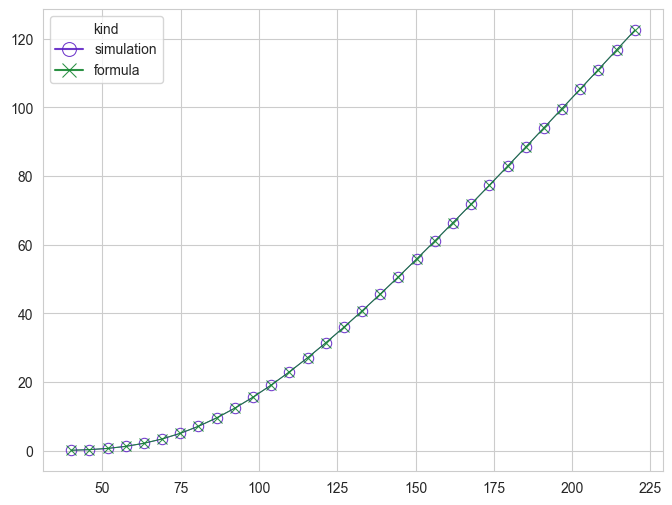

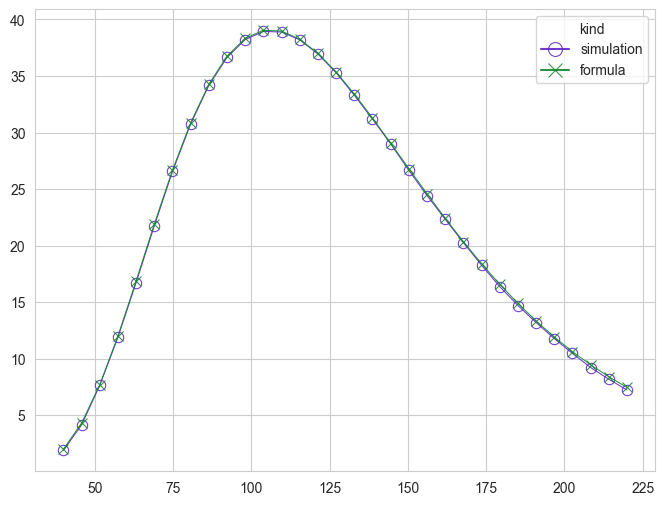

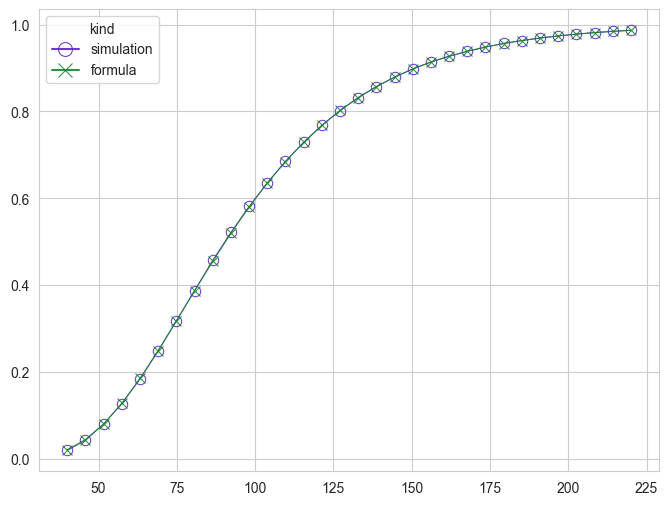

In [68]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

c1 = "#5F23C6"
c2 = "#148530"

# Define marker styles
marker_styles = {
    "o": {"facecolor": "none", "edgecolor": c1, "linewidth": 1.5, "markersize": 10},
    "x": {"facecolor": "none", "edgecolor": None, "linewidth": 1.5, "markersize": 10},
}

mc = pd.read_csv("montecarlo.csv")
mc["kind"] = "simulation"
an = pd.read_csv("analytic.csv")
an["kind"] = "formula"

custom_colors = {"simulation": c1, "formula": c2}
markers = {"simulation": "o", "formula": "x"}

df = pd.concat([mc, an])

for y in ["pv", "vega", "delta"]:
    fig, ax = plt.subplots(figsize=(8, 6))

    for kind in df["kind"].unique():
        subset = df[df["kind"] == kind]
        m = markers[kind]
        style = marker_styles[m].copy()

        if style["edgecolor"] is None:
            style["edgecolor"] = custom_colors[kind]

        ax.plot(
            subset["spot"],
            subset[y],
            color=custom_colors[kind],
            marker=m,
            linestyle="-",
            alpha=0.9,
            linewidth=0.75,
            markersize=7.5,
            markeredgewidth=0.75,
            markeredgecolor=style["edgecolor"],
            markerfacecolor=style["facecolor"],
        )

    for kind in df["kind"].unique():
        ax.plot(
            [],
            [],
            color=custom_colors[kind],
            marker=markers[kind],
            linestyle="-",
            alpha=0.9,
            markersize=10,
            markeredgewidth=0.75,
            markeredgecolor=marker_styles[markers[kind]]["edgecolor"],
            markerfacecolor=marker_styles[markers[kind]]["facecolor"],
            label=kind,
        )

    ax.legend(title="kind")
    plt.show()